## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
import tensorflow as tf
import numpy as np

In [2]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


### Find no.of samples are there in training and test datasets

In [3]:
print("Total train samples: ",x_train.shape[0])

Total train samples:  60000


In [4]:
print("Total test samples: ",x_test.shape[0])

Total test samples:  10000


In [5]:
print("Total #Labels: ",len(np.unique(y_test)))

Total #Labels:  10


### Find dimensions of an image in the dataset

In [6]:
print("Dimensions of each image: ", x_train[0].shape)

Dimensions of each image:  (28, 28)


### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
trainY = tf.keras.utils.to_categorical(y_train, num_classes=10)
testY = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train = x_train/255

In [0]:
x_test = x_test/255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

### Import the necessary layers from keras to build the model

In [0]:
tf.keras.backend.clear_session()
#Initialize model, reshape & normalize data
model = tf.keras.models.Sequential()

#Reshape data from 2D (28,28) to 3D (28, 28, 1)
#model.add(tf.keras.layers.Reshape((28,28,1),input_shape=(28,28,)))
#normalize data
model.add(tf.keras.layers.BatchNormalization())

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [12]:

#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3),activation='relu'))

#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
#Flatten the output
model.add(tf.keras.layers.Flatten())
#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

W0818 11:33:04.395230 140139970332544 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
model.summary()

ValueError: ignored

In [0]:
chpt = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto')

In [16]:
#Train the model
model.fit(x_train,trainY,validation_data=(x_test,testY),epochs=10,batch_size=10000, callbacks=[chpt] )

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 7s 120us/sample - loss: 1.5984 - acc: 0.4334 - val_loss: 1.5709 - val_acc: 0.5228
Epoch 2/10
60000/60000 [==============================] - 2s 34us/sample - loss: 0.7566 - acc: 0.7339 - val_loss: 1.2370 - val_acc: 0.6315
Epoch 3/10
60000/60000 [==============================] - 2s 35us/sample - loss: 0.5773 - acc: 0.7940 - val_loss: 0.9969 - val_acc: 0.7526
Epoch 4/10
60000/60000 [==============================] - 2s 35us/sample - loss: 0.4943 - acc: 0.8255 - val_loss: 0.9929 - val_acc: 0.7502
Epoch 5/10
60000/60000 [==============================] - 2s 35us/sample - loss: 0.4439 - acc: 0.8423 - val_loss: 0.9343 - val_acc: 0.7483
Epoch 6/10
60000/60000 [==============================] - 2s 35us/sample - loss: 0.4090 - acc: 0.8550 - val_loss: 0.8952 - val_acc: 0.7686
Epoch 7/10
60000/60000 [==============================] - 2s 35us/sample - loss: 0.3816 - acc: 0.8650 - val_loss: 0

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
tf.keras.backend.clear_session()
#Initialize model, reshape & normalize data
model = tf.keras.models.Sequential()

#Reshape data from 2D (28,28) to 3D (28, 28, 1)
#model.add(tf.keras.layers.Reshape((28,28,1),input_shape=(28,28,)))

#normalize data
model.add(tf.keras.layers.BatchNormalization())


#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3),activation='relu'))

#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))

#Add MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

#Flatten the output
model.add(tf.keras.layers.Flatten())

#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Add another dropout layer
model.add(tf.keras.layers.Dropout(0.25))

#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
chpt = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto')

In [20]:
#Train the model
model.fit(x_train,trainY,validation_data=(x_test,testY),epochs=10,batch_size=10000, callbacks=[chpt] )

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 2s 36us/sample - loss: 1.6760 - acc: 0.4879 - val_loss: 1.5887 - val_acc: 0.6199
Epoch 2/10
60000/60000 [==============================] - 2s 32us/sample - loss: 0.8602 - acc: 0.6939 - val_loss: 1.1340 - val_acc: 0.7040
Epoch 3/10
60000/60000 [==============================] - 2s 32us/sample - loss: 0.6730 - acc: 0.7565 - val_loss: 1.1482 - val_acc: 0.7708
Epoch 4/10
60000/60000 [==============================] - 2s 33us/sample - loss: 0.5786 - acc: 0.7910 - val_loss: 1.0182 - val_acc: 0.7821
Epoch 5/10
60000/60000 [==============================] - 2s 33us/sample - loss: 0.5216 - acc: 0.8107 - val_loss: 1.0212 - val_acc: 0.7844
Epoch 6/10
60000/60000 [==============================] - 2s 33us/sample - loss: 0.4823 - acc: 0.8277 - val_loss: 1.0115 - val_acc: 0.7932
Epoch 7/10
60000/60000 [==============================] - 2s 33us/sample - loss: 0.4519 - acc: 0.8404 - val_loss: 0.

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization (BatchNo multiple                  4         
_________________________________________________________________
conv2d (Conv2D)              multiple                  320       
_________________________________________________________________
conv2d_1 (Conv2D)            multiple                  9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) multiple                  0         
_________________________________________________________________
flatten (Flatten)            multiple                  0         
_________________________________________________________________
dense (Dense)                multiple                  589952    
_________________________________________________________________
dropout (Dropout)            multiple                  0

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
img_generator= tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,horizontal_flip=True)

In [0]:
img_generator.fit(x_train)
img_generator.fit(x_test)


In [24]:
testY.shape

(10000, 10)

In [25]:
x_test.shape

(10000, 28, 28, 1)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

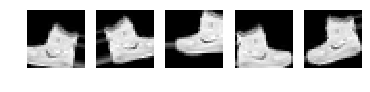

In [26]:
from matplotlib import pyplot as plt
gen = img_generator.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [27]:
BS= 1000
model.fit_generator(img_generator.flow(x_train, trainY, batch_size=BS),	validation_data=(x_test,testY), steps_per_epoch=len(x_train) // BS,	epochs=10)

Epoch 1/10
60/60 [==============================] - 10s 168ms/step - loss: 1.3908 - acc: 0.5029 - val_loss: 1.1109 - val_acc: 0.6455
Epoch 2/10
60/60 [==============================] - 10s 169ms/step - loss: 0.9406 - acc: 0.6576 - val_loss: 0.9796 - val_acc: 0.6333
Epoch 3/10
60/60 [==============================] - 10s 169ms/step - loss: 0.8349 - acc: 0.6942 - val_loss: 0.7614 - val_acc: 0.7155
Epoch 4/10
60/60 [==============================] - 10s 169ms/step - loss: 0.7770 - acc: 0.7141 - val_loss: 0.6449 - val_acc: 0.7434
Epoch 5/10
60/60 [==============================] - 10s 170ms/step - loss: 0.7442 - acc: 0.7247 - val_loss: 0.5946 - val_acc: 0.7660
Epoch 6/10
60/60 [==============================] - 10s 168ms/step - loss: 0.7165 - acc: 0.7340 - val_loss: 0.5722 - val_acc: 0.7738
Epoch 7/10
60/60 [==============================] - 10s 168ms/step - loss: 0.6914 - acc: 0.7410 - val_loss: 0.5391 - val_acc: 0.7856
Epoch 8/10
60/60 [==============================] - 10s 168ms/step - 

###  Report the final train and validation accuracy

In [31]:
print("Final Train accuracy: ", model.evaluate(x_train, trainY)[0]*100)
print("Validation accuracy: ", model.evaluate(x_test,testY)[0]*100)

60000/60000 [==============================] - 4s 73us/sample - loss: 0.4860 - acc: 0.8139
Final Train accuracy:  48.60246111710866
10000/10000 [==============================] - 1s 73us/sample - loss: 0.5061 - acc: 0.8048
Validation accuracy:  50.61147818565369


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

### **Load CIFAR10 dataset**

In [32]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170500096/170498071 [==============================] - 2s 0us/step


In [42]:
print("Total test samples: ",x_train.shape)

Total test samples:  (50000, 32, 32, 3)


In [36]:
print("Total test samples: ",x_test.shape[0])

Total test samples:  10000


In [37]:
print("Total #Labels: ",len(np.unique(y_test)))

Total #Labels:  10


### Find dimensions of an image in the dataset

In [38]:
print("Dimensions of each image: ", x_train[0].shape)

Dimensions of each image:  (32, 32, 3)


### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
trainY = tf.keras.utils.to_categorical(y_train, num_classes=10)
testY = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train = x_train/255

In [0]:
x_test = x_test/255

### Import the necessary layers from keras to build the model

In [0]:
tf.keras.backend.clear_session()
#Initialize model, reshape & normalize data
model = tf.keras.models.Sequential()

#Reshape data from 2D (28,28) to 3D (28, 28, 1)
#model.add(tf.keras.layers.Reshape((28,28,1),input_shape=(28,28,)))

#normalize data
model.add(tf.keras.layers.BatchNormalization())


#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3),activation='relu'))

#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))

#Add MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

#Flatten the output
model.add(tf.keras.layers.Flatten())

#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Add another dropout layer
model.add(tf.keras.layers.Dropout(0.25))

#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [45]:
#Train the model
model.fit(x_train,trainY,validation_data=(x_test,testY),epochs=10,batch_size=10000 )

Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 7s 148us/sample - loss: 2.2487 - acc: 0.1712 - val_loss: 2.3025 - val_acc: 0.1763
Epoch 2/10
50000/50000 [==============================] - 3s 65us/sample - loss: 2.0345 - acc: 0.2644 - val_loss: 2.2005 - val_acc: 0.1964
Epoch 3/10
50000/50000 [==============================] - 3s 65us/sample - loss: 1.8893 - acc: 0.3280 - val_loss: 2.1538 - val_acc: 0.2045
Epoch 4/10
50000/50000 [==============================] - 3s 65us/sample - loss: 1.7691 - acc: 0.3702 - val_loss: 2.1148 - val_acc: 0.2168
Epoch 5/10
50000/50000 [==============================] - 3s 66us/sample - loss: 1.6675 - acc: 0.4056 - val_loss: 2.0818 - val_acc: 0.2561
Epoch 6/10
50000/50000 [==============================] - 3s 66us/sample - loss: 1.5695 - acc: 0.4445 - val_loss: 2.0458 - val_acc: 0.2668
Epoch 7/10
50000/50000 [==============================] - 3s 66us/sample - loss: 1.4895 - acc: 0.4724 - val_loss: 1

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
data_gen=tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,horizontal_flip=True)

### **Prepare/fit the generator.**

In [0]:
data_gen.fit(x_train)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

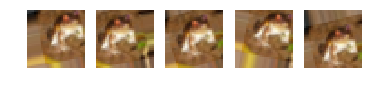

In [49]:
from matplotlib import pyplot as plt
gen = data_gen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()